In [1]:
pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import pandas as pd
import numpy as np

from scipy.optimize import minimize
from scipy.linalg import lstsq
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from typing import Dict, Union, Tuple
from IPython.display import Image

In [3]:
url = 'https://raw.githubusercontent.com/OscarEngelbrektson/SyntheticControlMethods/refs/heads/master/examples/datasets/german_reunification.csv'
df  = pd.read_csv(url)
df[['country', 'year', 'gdp', 'infrate', 'trade', 'schooling', 'invest60', 'invest70', 'invest80']].head()

,country,year,gdp,infrate,trade,schooling,invest60,invest70,invest80
0,USA,1960,2879,NaN,9.693181,43.799999,NaN,NaN,NaN
1,USA,1961,2929,1.075182,9.444655,NaN,NaN,NaN,NaN
2,USA,1962,3103,1.116071,9.429324,NaN,NaN,NaN,NaN
3,USA,1963,3227,1.214128,9.470706,NaN,NaN,NaN,NaN
4,USA,1964,3420,1.308615,9.725879,NaN,NaN,NaN,NaN


In [4]:
fig = go.Figure()

countries = df['country'].unique()
for country in countries:
    country_data = df[df['country'] == country]
    if country == 'West Germany':
        fig.add_trace(go.Scatter(x=country_data['year'], y=country_data['gdp'], mode='lines', name=country,
                                 line=dict(color='blue'), showlegend=False))
    else:
        fig.add_trace(go.Scatter(x=country_data['year'], y=country_data['gdp'], mode='lines', name=country, opacity=0.5,
                                 line=dict(color='lightgrey'), showlegend=False))

fig.add_annotation(x=2006, y=29000, text="West<br>Germany", font=dict(family="dm sans", color='blue'), showarrow=False, arrowhead=1, arrowsize=1, arrowwidth=1, ax=20)

fig.add_annotation(
    x=0.01, y=-0.17, xref="paper", yref="paper",
    # text=(
    #     "GDP is Purchasing Power Parity (PPP)-adjusted and measured in 2002 US$.<br>"
    #     "Source: Comparative Politics and the Synthetic Control Method (Abadie et al. 2015).<br>"
    #     "Dataset: "
    #     "<a href='https://github.com/OscarEngelbrektson/SyntheticControlMethods/blob/master/examples/datasets/german_reunification.csv'>"
    #     "Download Source</a>."
    # ),
    text="GDP is Purchasing Power Parity (PPP)-adjusted and measured in 2002 US$<br>Source: Comparative Politics and the Synthetic Control Method (Abadie et al. 2015)<br>Download Source: https://github.com/OscarEngelbrektson/SyntheticControlMethods/blob/master/examples/datasets/german_reunification.csv",
    showarrow=False, font=dict(size=9, color="darkgrey", family='dm sans'), align="left"
)


fig.add_vline(x=1990, line=dict(color="lightcoral", width=2, dash="dash")
              ,annotation_text="German<br>Reunification", annotation_position="top right"
              ,annotation_font=dict(color="lightcoral", size=14, family="dm sans"))


fig.update_layout(
    title='Uptrends in per Capita GDP: West Germany vs. Others<br>during 1960-2003',
    xaxis_title='',
    yaxis_title='Per Capita GDP<br>(PPP, 2002 US$)',
    yaxis_tickprefix='$',
    template='plotly_white',
    height=600,width=800,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    margin=dict(t=70, r=20),
)

fig.update_xaxes(
    # showgrid=False,
    # linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title_text='Year',
    title_font=dict(color='grey', size=10, family='dm sans'),
)

fig.update_yaxes(
    # title_text='Gap in GDP per Capita',
    title_font=dict(color='grey', size=10, family='dm sans'),
    showgrid=False,
    linecolor='lightgrey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
)

# Show plot
fig.show()
fig.write_image("overall_trend.png", scale=6)

All relevant countries are uptrended in GDP per capita from 1960 to 2003

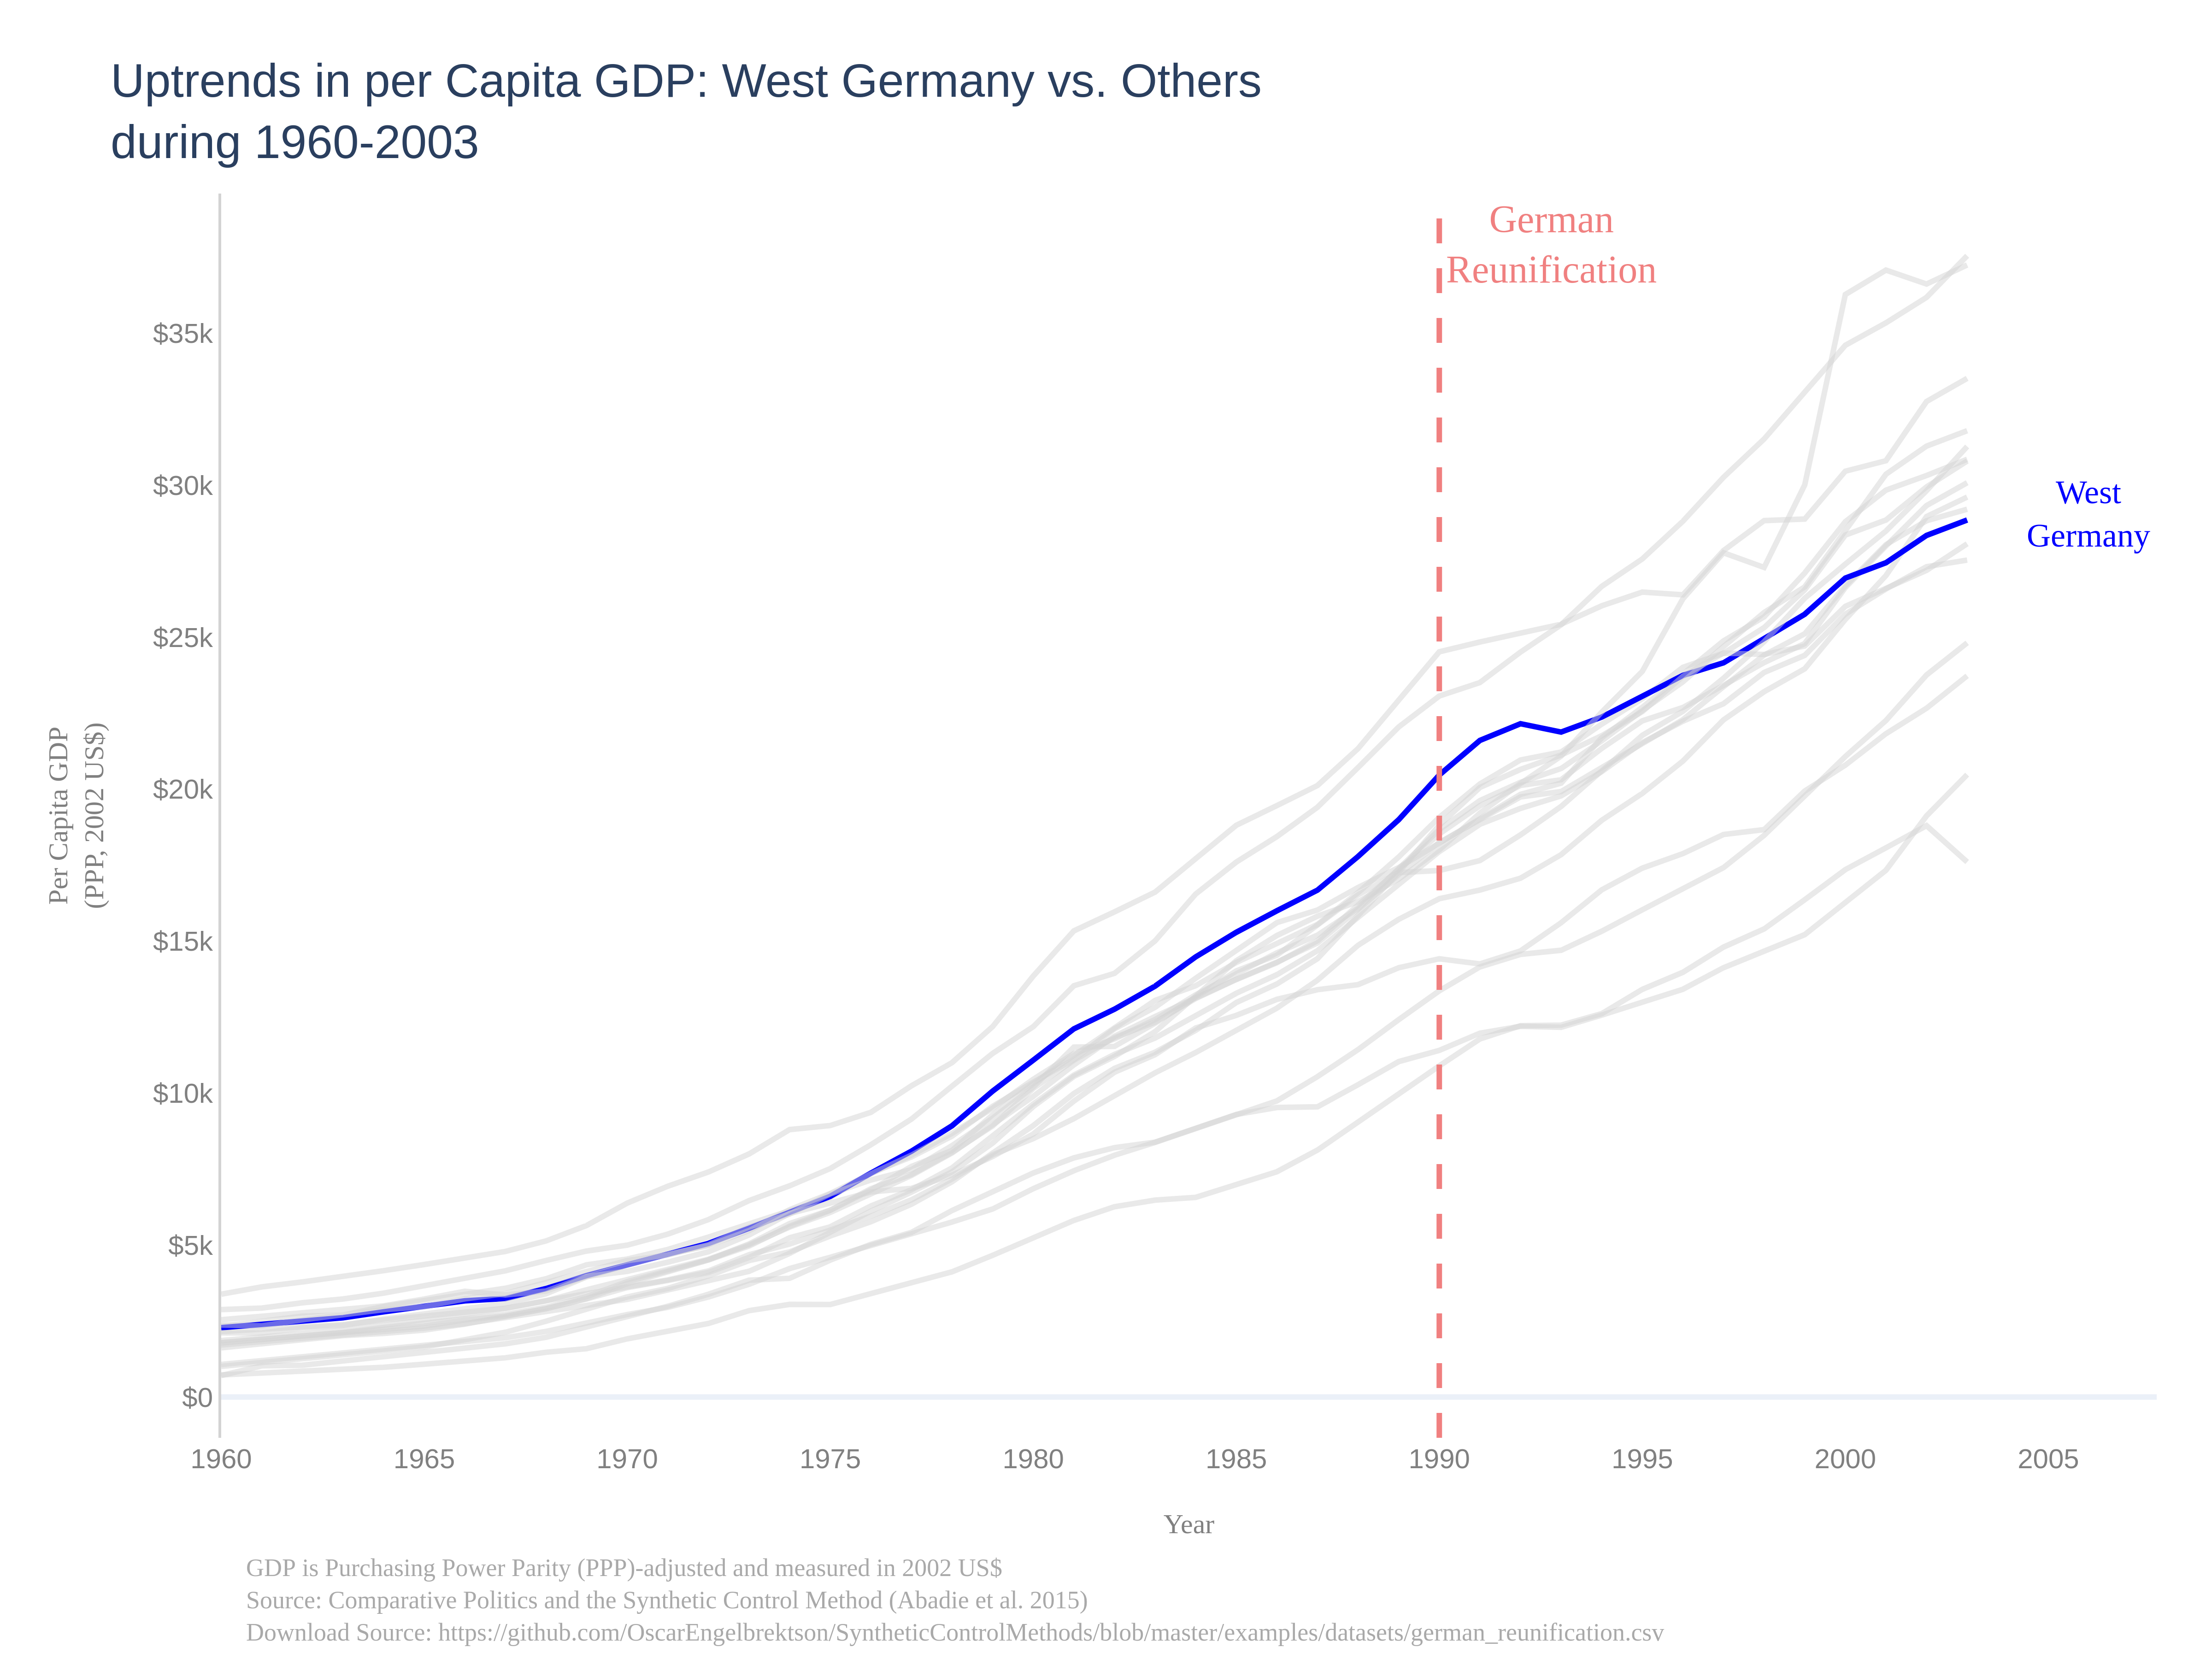

In [5]:
Image(filename="overall_trend.png")

In [6]:
def prepare_covariate(df: pd.DataFrame,
                      covariate_spec: Dict[str, Tuple[str, str, Tuple[int, int]]],
                      id_col: str = 'country',
                      time_col: str = 'year') -> pd.DataFrame:
    """
    Build the covariate matrix which can also affect the outcome of an ID

    Parameters
    ----------
    df : Original pd.DataFrame with columns: country, year, gdp, infrate, trade, schooling, invest60, invest70, invest80, industry
    covariate_spec : Covariate calculation specifications
    id_col : Unit identifier column (country)
    time_col : Time column (year)

    Returns
    -------
    cov_df : Covariate pd.DataFrame with countries as rows, covariates as columns
    """


    cov_list = list(covariate_spec.keys())
    cov_rows = []

    # Build covariates for each ID

    for unit, grp in df.groupby(id_col):
        row = {id_col: unit}
        for cov_name, (col, agg_method, yrs) in covariate_spec.items():
            if isinstance(yrs, tuple):  # average over interval
                start, end = yrs
                vals = grp[(grp[time_col] >= start) & (grp[time_col] <= end)][col]
                row[cov_name] = vals.agg(agg_method) if not vals.empty else np.nan
            elif isinstance(yrs, list):  # average over point-wise
                start, end = yrs
                vals = grp[grp[time_col].isin([start, end])][col]
                row[cov_name] = vals.agg(agg_method) if not vals.empty else np.nan
            else:  # single year
                vals = grp[grp[time_col] == yrs][col]
                row[cov_name] = vals.iloc[0] if not vals.empty else np.nan
        cov_rows.append(row)

    return pd.DataFrame(cov_rows).set_index(id_col)

# PRE-TREATMENT FIT

## INPUTS AND COVARIATES DEFINITION

In [7]:
time_col, id_col, outcome_col = 'year', 'country', 'gdp'
treated_unit, treatment_year = 'West Germany', 1990
df_pivot = df.pivot(index=time_col, columns=id_col, values=outcome_col).sort_index()
display(df_pivot.head(5))
# Covariate Specification which can affect West Germany GDP
covariate_spec = {
    'gdp_avg': ('gdp', 'mean', (1981, treatment_year)),           # AVG GDP per capita 1981-90
    'trade_avg': ('trade', 'mean', (1981, treatment_year)),       # Avg Trade openness 1981-90
    'infrate_avg': ('infrate', 'mean', (1981, treatment_year)),   # Avg Inflation rate 1981-90
    'industry_avg': ('industry', 'mean', (1981, 1989)),           # Avg Industry share 1981-1989
    'schooling_avg': ('schooling', 'mean', [1980, 1985]),         # Avg Schooling 1980 and 85
    'invest80': ('invest80', 'mean', (1980, 1984))                # Avg Investment rate 1980-85 (using invest80 as proxy)
    # 'gdp1980': ('gdp', 'mean', 1980),           # AVG GDP per capita 1981-90
    # 'gdp1975': ('gdp', 'mean', 1975),           # AVG GDP per capita 1981-90
    # 'gdp1970': ('gdp', 'mean', 1970),           # AVG GDP per capita 1981-90
    # 'gdp1965': ('gdp', 'mean', 1965),           # AVG GDP per capita 1981-90
    # 'gdp1960': ('gdp', 'mean', 1960),           # AVG GDP per capita 1981-90

}
cov_df = prepare_covariate(df, covariate_spec)
display(cov_df)

country,Australia,Austria,Belgium,Denmark,France,Greece,Italy,Japan,Netherlands,New Zealand,Norway,Portugal,Spain,Switzerland,UK,USA,West Germany
year,,,,,,,,,,,,,,,,,
1960,2373,1796,1782,2329,1858,707,1620,1010,2113,2545,1713,728,1074,3387,2158,2879,2284
1961,2346,1899,1883,2485,1959,1028,1763,1143,2111,2659,1823,783,1201,3625,2216,2929,2388
1962,2539,1977,2018,2665,2099,1049,1900,1262,2275,2713,1905,848,1335,3788,2276,3103,2527
1963,2717,2074,2122,2700,2205,1188,2021,1374,2360,2866,1991,905,1467,3946,2386,3227,2610
1964,2873,2224,2288,2980,2367,1316,2093,1546,2566,3001,2112,979,1554,4158,2534,3420,2806


,gdp_avg,trade_avg,infrate_avg,industry_avg,schooling_avg,invest80
country,,,,,,
Australia,14368.1,33.776868,8.127678,33.315445,47.950001,29.695999
Austria,14817.0,74.630803,3.529565,35.638066,60.899999,26.642000
Belgium,14347.3,133.611792,4.580300,33.571954,32.099999,21.875999
Denmark,14857.1,69.557355,5.945661,27.278466,42.950001,22.217999
France,14293.2,44.736920,6.368286,32.489393,35.399999,27.236000
Greece,9438.4,43.007217,19.040849,30.491523,21.700001,24.002001
Italy,13869.7,42.683143,9.721693,36.136559,29.750000,26.728001
Japan,13714.8,23.042788,2.058197,39.583247,40.900002,34.986000
Netherlands,14462.3,106.078918,2.543722,32.995303,44.399999,21.840000


## SYNTHETIC CONTROL MODELING

In [8]:
def synthetic_control_method(df: pd.DataFrame,
                             cov_df: pd.DataFrame,
                             treated_unit: str,
                             treatment_year: int,
                             method: str = 'SLSQP',
                             verbose: bool = False) -> Tuple[pd.DataFrame, Dict, np.array]:
    """
    Run synthetic control by finding optimal weights between treated unit and the others (donors)

    Parameters
    ----------
    df : GDP by years by countries, (index = years, columns: GDP of each non-treated countries (donors)). Original data must be pivoted
    cov_df : Pre-computed covariate pd.DataFrame above
    treated_unit : str Treatment country (i.e. West Germany)
    treatment_year : int Treatment year
    method : str Scipy Optimization method
    verbose : bool Print diagnostics

    Returns
    -------
    synth_df : Synthetic control pd.DataFrame results
    w_opt : dict of donor weights
    v_opt : Covariate weights np.ndarray
    """

    # Define pre-treatment period
    pre_mask = df.index < treatment_year

    # Extract treated and control outcomes
    Y_tr = df.loc[pre_mask, treated_unit].values
    Y_co = df.loc[pre_mask].drop(columns=[treated_unit]).values

    # Extract covariates to matrix
    cov_list = cov_df.columns.tolist()
    Z_tr = cov_df.loc[treated_unit].values
    Z_co = cov_df.drop(index=treated_unit).values

    # Need to Normalize covariates to [0,1]

    Z_min = Z_co.min(axis=0)
    Z_max = Z_co.max(axis=0)
    Z_range = Z_max - Z_min
    Z_range = np.where(Z_range == 0, 1e-9, Z_range)  # Avoid division by zero

    Z_tr = (Z_tr - Z_min) / Z_range
    Z_co = (Z_co - Z_min[np.newaxis, :]) / Z_range[np.newaxis, :]


    J = Z_co.shape[0]  # number of donors
    p = Z_co.shape[1]  # number of covariates

    # Optimize W given V
    def synth_w_from_v(v):
        V = np.diag(v)
        def obj_w(w):
            d = Z_tr - Z_co.T.dot(w)
            return d.T.dot(V).dot(d)
        cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
        bounds = [(0, 1)] * J

        # Initial guess for W: Uniform

        w0 = np.ones(J) / J

        res = minimize(obj_w, w0, bounds=bounds, constraints=cons, method=method)
        return res.x

    # Optimize V to match the outcome
    def outer_obj(v):
        w = synth_w_from_v(v)
        resid = Y_tr - Y_co.dot(w)
        return np.sum(resid**2)

    cons_v = ({'type': 'eq', 'fun': lambda v: np.sum(v) - 1},)
    bounds_v = [(0, 1)] * p

    # Initial guess for V: Uniform
    v0 = np.ones(p) / p

    res_v = minimize(outer_obj, v0, bounds=bounds_v, constraints=cons_v, method=method)

    v_opt = res_v.x
    w_vec = synth_w_from_v(v_opt)

    # Map weights back to donor units
    donors = [u for u in df.columns if u != treated_unit]
    w_opt = dict(zip(donors, w_vec))

    if verbose:
        print(f"Country: {treated_unit}")
        print("Optimal V:", v_opt)
        print("Top 3 donor weights:", sorted(w_opt.items(), key=lambda x: x[1], reverse=True)[:3])

    # Construct synthetic series
    synth_vals = df.drop(columns=[treated_unit]).values.dot(w_vec)

    synth_df = pd.DataFrame({
        'year': df.index,
        'Treated': df[treated_unit].values,
        'Synthetic': synth_vals,
        'Gap': df[treated_unit].values - synth_vals
    })

    return synth_df, w_opt, v_opt

In [9]:
synth_df, w_opt, v_opt = synthetic_control_method(df_pivot, cov_df, treated_unit, treatment_year, method='SLSQP')
synth_df_Germany = synth_df.copy()
weight_table = pd.DataFrame({
    'Donor Unit': list(w_opt.keys()),
    'Weight': list(w_opt.values())
}).sort_values(by='Weight', ascending=False)
weight_table['Weight'] = weight_table['Weight'].round(4)
print("\nDonor Weights Table:")
print(weight_table.to_markdown(index=False))
print("\Importance Weights Table:")
print(v_opt)


Donor Weights Table:
| Donor Unit   |   Weight |
|:-------------|---------:|
| Austria      |   0.408  |
| USA          |   0.2156 |
| Japan        |   0.1628 |
| Switzerland  |   0.1114 |
| Netherlands  |   0.1022 |
| Denmark      |   0      |
| France       |   0      |
| Italy        |   0      |
| Spain        |   0      |
| Greece       |   0      |
| Australia    |   0      |
| Belgium      |   0      |
| Portugal     |   0      |
| Norway       |   0      |
| New Zealand  |   0      |
| UK           |   0      |
\Importance Weights Table:
[0.16667111 0.16666946 0.16666578 0.16666743 0.16666743 0.16667111]


West Germany =  0.41 x Austria + 0.22 x USA + 0.16 x Japan + 0.11 x Switzerlands + 0.1 x Netherlands

In [10]:

# My model (blue) data from screenshot
model_weights = weight_table[weight_table.Weight > 0]

# Reference model (grey) data
reference_weights = {
    'Austria': 0.42,
    'USA': 0.22,
    'Japan': 0.16,
    'Switzerland': 0.11,
    'Netherlands': 0.09
}


# Create a DataFrame
weight_plot = pd.DataFrame({
    'Countries': list(model_weights['Donor Unit'].unique()),
    'Model': list(model_weights['Weight']),
    'Reference': [reference_weights[state] for state in list(model_weights['Donor Unit'].unique())]
})
display(weight_plot)

# Create a bar chart
fig = go.Figure()

# Add bars for My Model
fig.add_trace(go.Bar(
    x=weight_plot['Countries'],
    y=weight_plot['Model'],
    # width=0.5,
    name='Our Model',
    marker_color='skyblue'
))

# Add bars for Reference
fig.add_trace(go.Bar(
    x=weight_plot['Countries'],
    y=weight_plot['Reference'],
    # width=0.25,
    name='Abadie et. al. (2015)',
    marker_color='lightgrey'
))

fig.update_xaxes(
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title='Countries',
    title_font=dict(color='grey', size=10, family='dm sans'),

)

fig.update_yaxes(
    showgrid=False,
    title='Weight',
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    title_font=dict(color='grey', size=10, family='dm sans'),
    tickcolor='grey',
)

# Update layout
fig.update_layout(
    title='Donor Weights in Modeling: Our model vs. Abadie et al. (2015)<br>Our model generates similar weights to the reference',
    barmode='group',
    width=550,
    height=200,
    template='plotly_white',
    legend=dict(
        x=-0.03,
        y=0.99,
        traceorder='normal',
        orientation='h',
        xanchor='left',
        yanchor='bottom',
        # bgcolor='rgba(255,255,255,0.5)',
        # bordercolor='black',
        # borderwidth=1
    ),
    margin=dict(t=115, r=10, b=5, l=50)
)

# Show figure
fig.show()
fig.write_image("weight_comparison.png", scale=6)

,Countries,Model,Reference
0,Austria,0.4080,0.42
1,USA,0.2156,0.22
2,Japan,0.1628,0.16
3,Switzerland,0.1114,0.11
4,Netherlands,0.1022,0.09


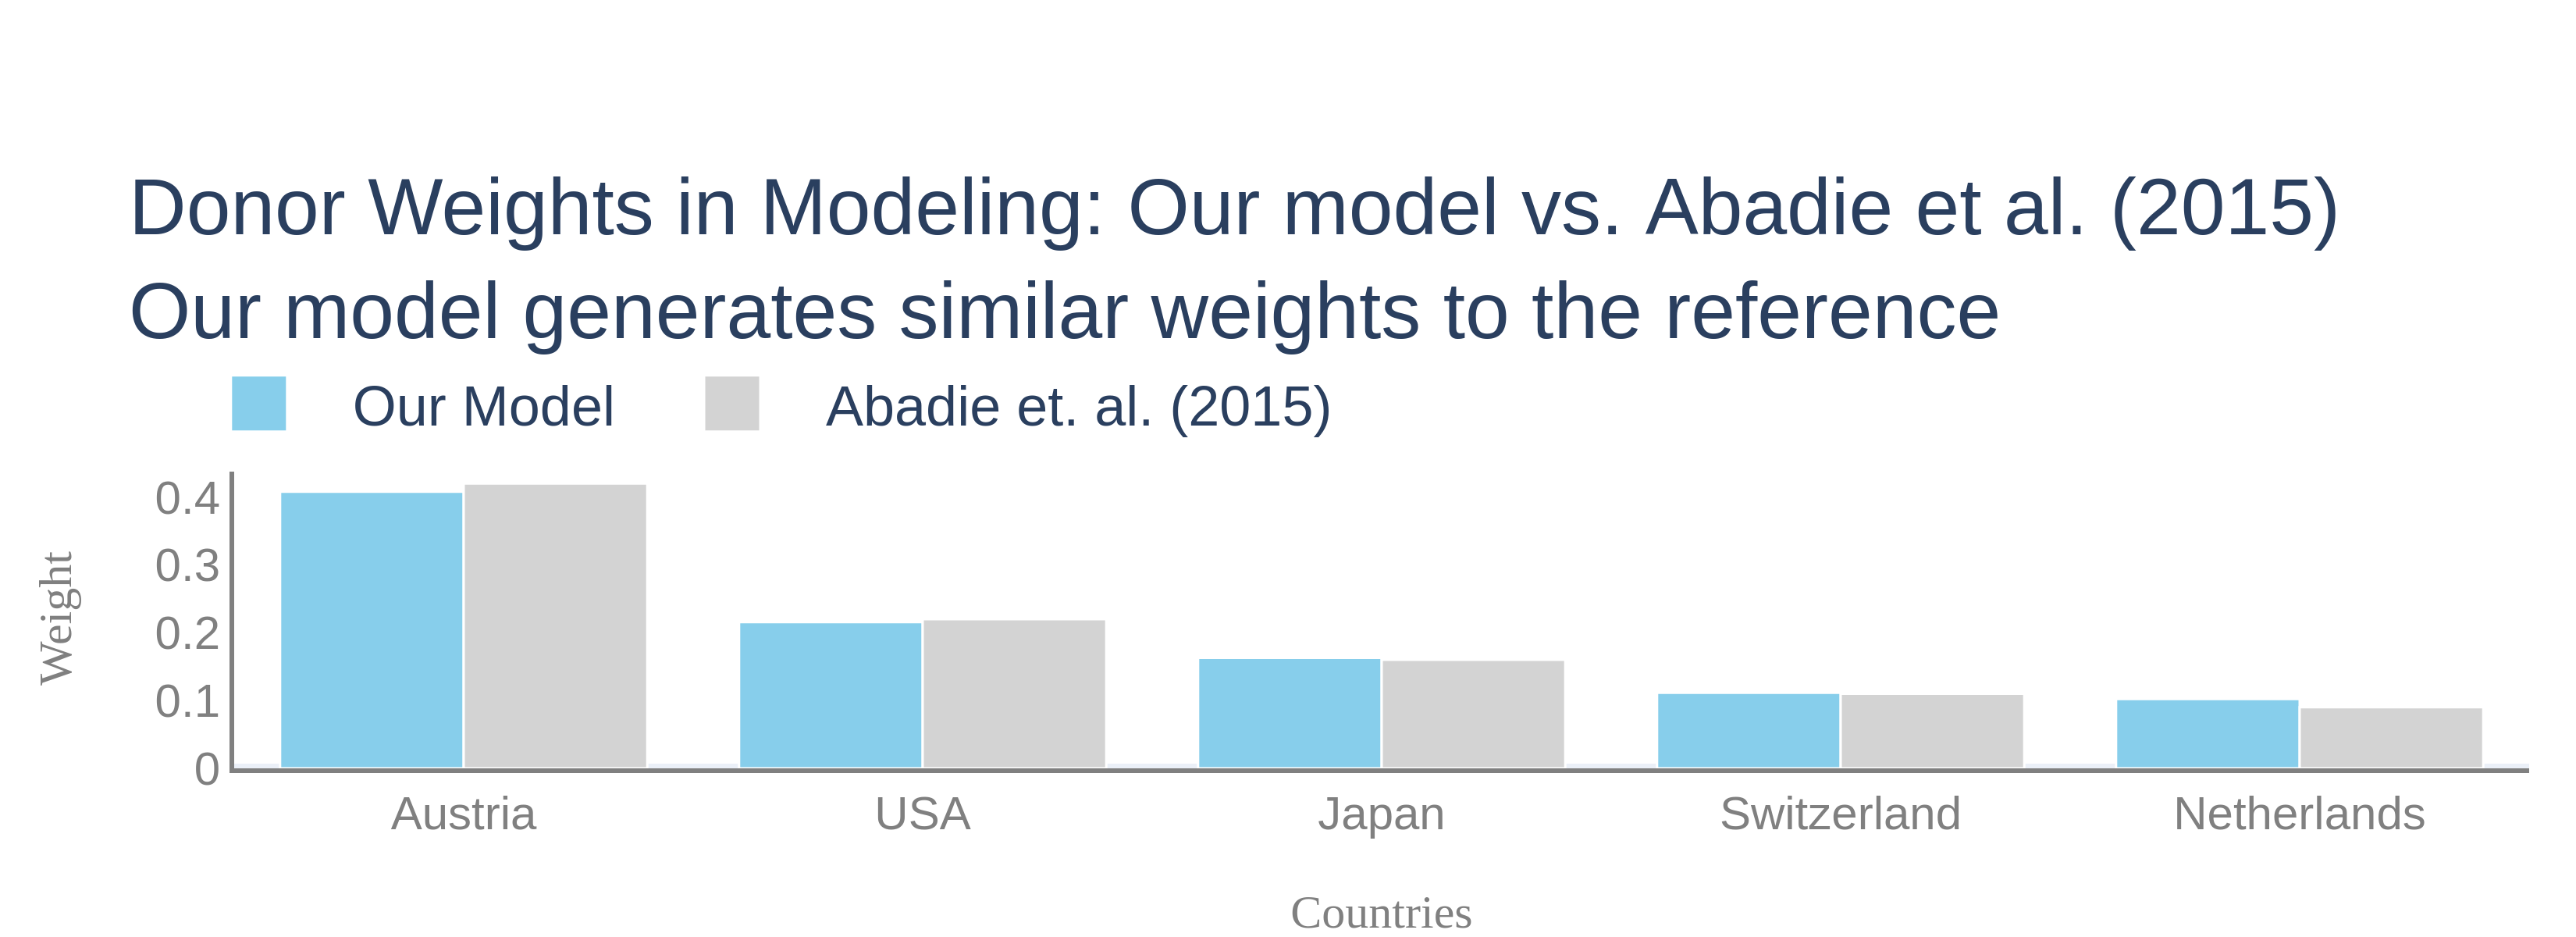

In [11]:
Image(filename="weight_comparison.png")

In [12]:
    # Variable name mappings for prettier output
    var_name_map = {
        'gdp_avg': 'GDP per capita',
        'infrate_avg': 'Inflation rate',
        'trade_avg': 'Trade openness',
        'schooling_avg': 'Schooling',
        'invest80': 'Investment rate',
        'industry_avg': 'Industry share'
    }
    title="Economic Growth Predictor Means before German Reunification"
    length_table=80

    # Get donor units and their weights
    donor_units = [unit for unit in cov_df.index if unit != treated_unit]
    weights = np.array([w_opt.get(unit, 0) for unit in donor_units])

    # Calculate values
    treated_values = cov_df.loc[treated_unit]
    donor_matrix = cov_df.loc[donor_units].values

    # Calculate Synthetic Values
    synthetic_values = donor_matrix.T @ weights
    # Simple average of all donors
    control_avg = cov_df.loc[donor_units].mean()

    # Print table header
    print(f"\n{title}")
    print("=" * length_table)
    print(f"{'':40}  {treated_unit:>15}            Average of")
    print(f"{'Variables':40} {'(Real)':>8} {'(Synthetic)':>9}  {len(donor_units)} OECD countries")
    print(f"{'':40} {'':>8} {'':>9}")
    print("-" * length_table)

    # Pretty print each variable
    for i, (var_code, var_val) in enumerate(treated_values.items()):

        var_name = var_name_map.get(var_code, var_code)

        real_val = var_val
        synthetic_val = synthetic_values[i]
        control_val = control_avg[var_code]


        if 'rate' in var_code.lower() or 'share' in var_code.lower():
            real_str = f"{real_val:.2f}"
            synth_str = f"{synthetic_val:.2f}"
            control_str = f"{control_val:.2f}"
        elif 'gdp' in var_code:
            real_str = f"{real_val:.0f}"
            synth_str = f"{synthetic_val:.0f}"
            control_str = f"{control_val:.0f}"
        else:
            real_str = f"{real_val:.2f}"
            synth_str = f"{synthetic_val:.2f}"
            control_str = f"{control_val:.2f}"

        print(f"{var_name:40} {real_str:>8} {synth_str:>9} {control_str:>15}")

    print("=" * length_table)

    print("\nNOTE: GDP per capita, inflation rate, trade openness, and industry share are")
    print("averaged for the 1981–90 period. Industry share is the average for 1981-1989. ")
    print("Schooling is the average for 1980 and 1985. Investment rate is averaged for ")
    print("for the 1980–85 period.")


Economic Growth Predictor Means before German Reunification
                                             West Germany            Average of
Variables                                  (Real) (Synthetic)  16 OECD countries
                                                           
--------------------------------------------------------------------------------
GDP per capita                              15809     15791           13669
Trade openness                              56.78     57.14           59.83
Inflation rate                               2.59      3.44            7.62
Industry share                              34.54     34.58           34.01
Schooling                                   55.50     55.02           38.66
Investment rate                             27.02     27.07           25.90

NOTE: GDP per capita, inflation rate, trade openness, and industry share are
averaged for the 1981–90 period. Industry share is the average for 1981-1989. 
Schooling is the average

In [13]:

fig = make_subplots(rows=2, cols=1,
                    row_heights=[0.7, 0.3],
                    shared_xaxes=True,
                    vertical_spacing=0.05)

fig.add_trace(go.Scatter(x=synth_df['year'], y=synth_df['Treated'],
                         mode='lines', name='Treated',
                         line=dict(color='blue'), showlegend=False),
              row=1, col=1)

fig.add_trace(go.Scatter(x=synth_df['year'], y=synth_df['Synthetic'],
                         mode='lines', name='Synthetic',
                         opacity=0.5, line=dict(color='rgba(0, 0, 255, 0.85)', dash="dash"), showlegend=False),
              row=1, col=1)


fig.add_annotation(x=2006, y=29000, text="West<br>Germany",
                   font=dict(family="dm sans", color='blue'), showarrow=False,
                   row=1, col=1)

fig.add_annotation(x=2006, y=34000, text="Synthetic<br>West<br>Germany",
                   font=dict(family="dm sans", color='rgba(0, 0, 255, 0.85)'),
                   opacity=0.5, showarrow=False,
                   row=1, col=1)

fig.add_vline(x=treatment_year, line=dict(color="lightcoral", width=2, dash="dash"),
              annotation_text="German<br>Reunification",
              annotation_position="top right",
              annotation_font=dict(color="lightcoral", size=14, family="dm sans"),
              row=1, col=1)

fig.update_yaxes(
    title_text='Per Capita GDP (PPP, 2002 US$)',
    title_font=dict(color='grey', size=10, family='dm sans'),
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    row=1, col=1
)

fig.update_xaxes(
    showgrid=False,
    row=1, col=1
)


fig.add_trace(go.Scatter(x=synth_df['year'], y=synth_df['Gap'],
                         mode='lines', name='Gap',
                         line=dict(color='grey'), showlegend=False),
              row=2, col=1)


fig.add_vline(x=treatment_year, line=dict(color="lightcoral", width=2, dash="dash"),
              row=2, col=1)

fig.add_hline(y=0, line=dict(color="grey", width=0.5, dash="dot"),
              row=2, col=1)

fig.update_xaxes(
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title_text='Year',
    title_font=dict(color='grey', size=10, family='dm sans'),
    row=2, col=1
)

fig.update_yaxes(
    title_text='Gap in GDP per Capita<br>(PPP, 2002 US$)',
    title_font=dict(color='grey', size=10, family='dm sans'),
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    row=2, col=1
)

fig.update_layout(
    title=dict(
        text="""For the first two years, no much difference.<br>In fact, the real West Germany did slightly better than its synthetic<br>However, their paths diverged since 1992""",
        font=dict(color='grey', size=16, family='dm sans'),
        x=0.015,
        xanchor='left'
    ),
    yaxis_tickprefix='$',
    template='plotly_white',
    height=700, width=800,
    margin=dict(t=90, r=20, b=15),
)

fig.show()
fig.write_image("west_germany_synthetic_gap.png", scale=6)

For the first two years, there wasn't much difference; in fact, the real West Germany did slightly better. However, starting in 1992, their paths split. The real West Germany's economic growth slowed down, while the synthetic version's economy continued to grow at its pre-reunification pace. This gap between the real and synthetic West Germany grew larger over time.

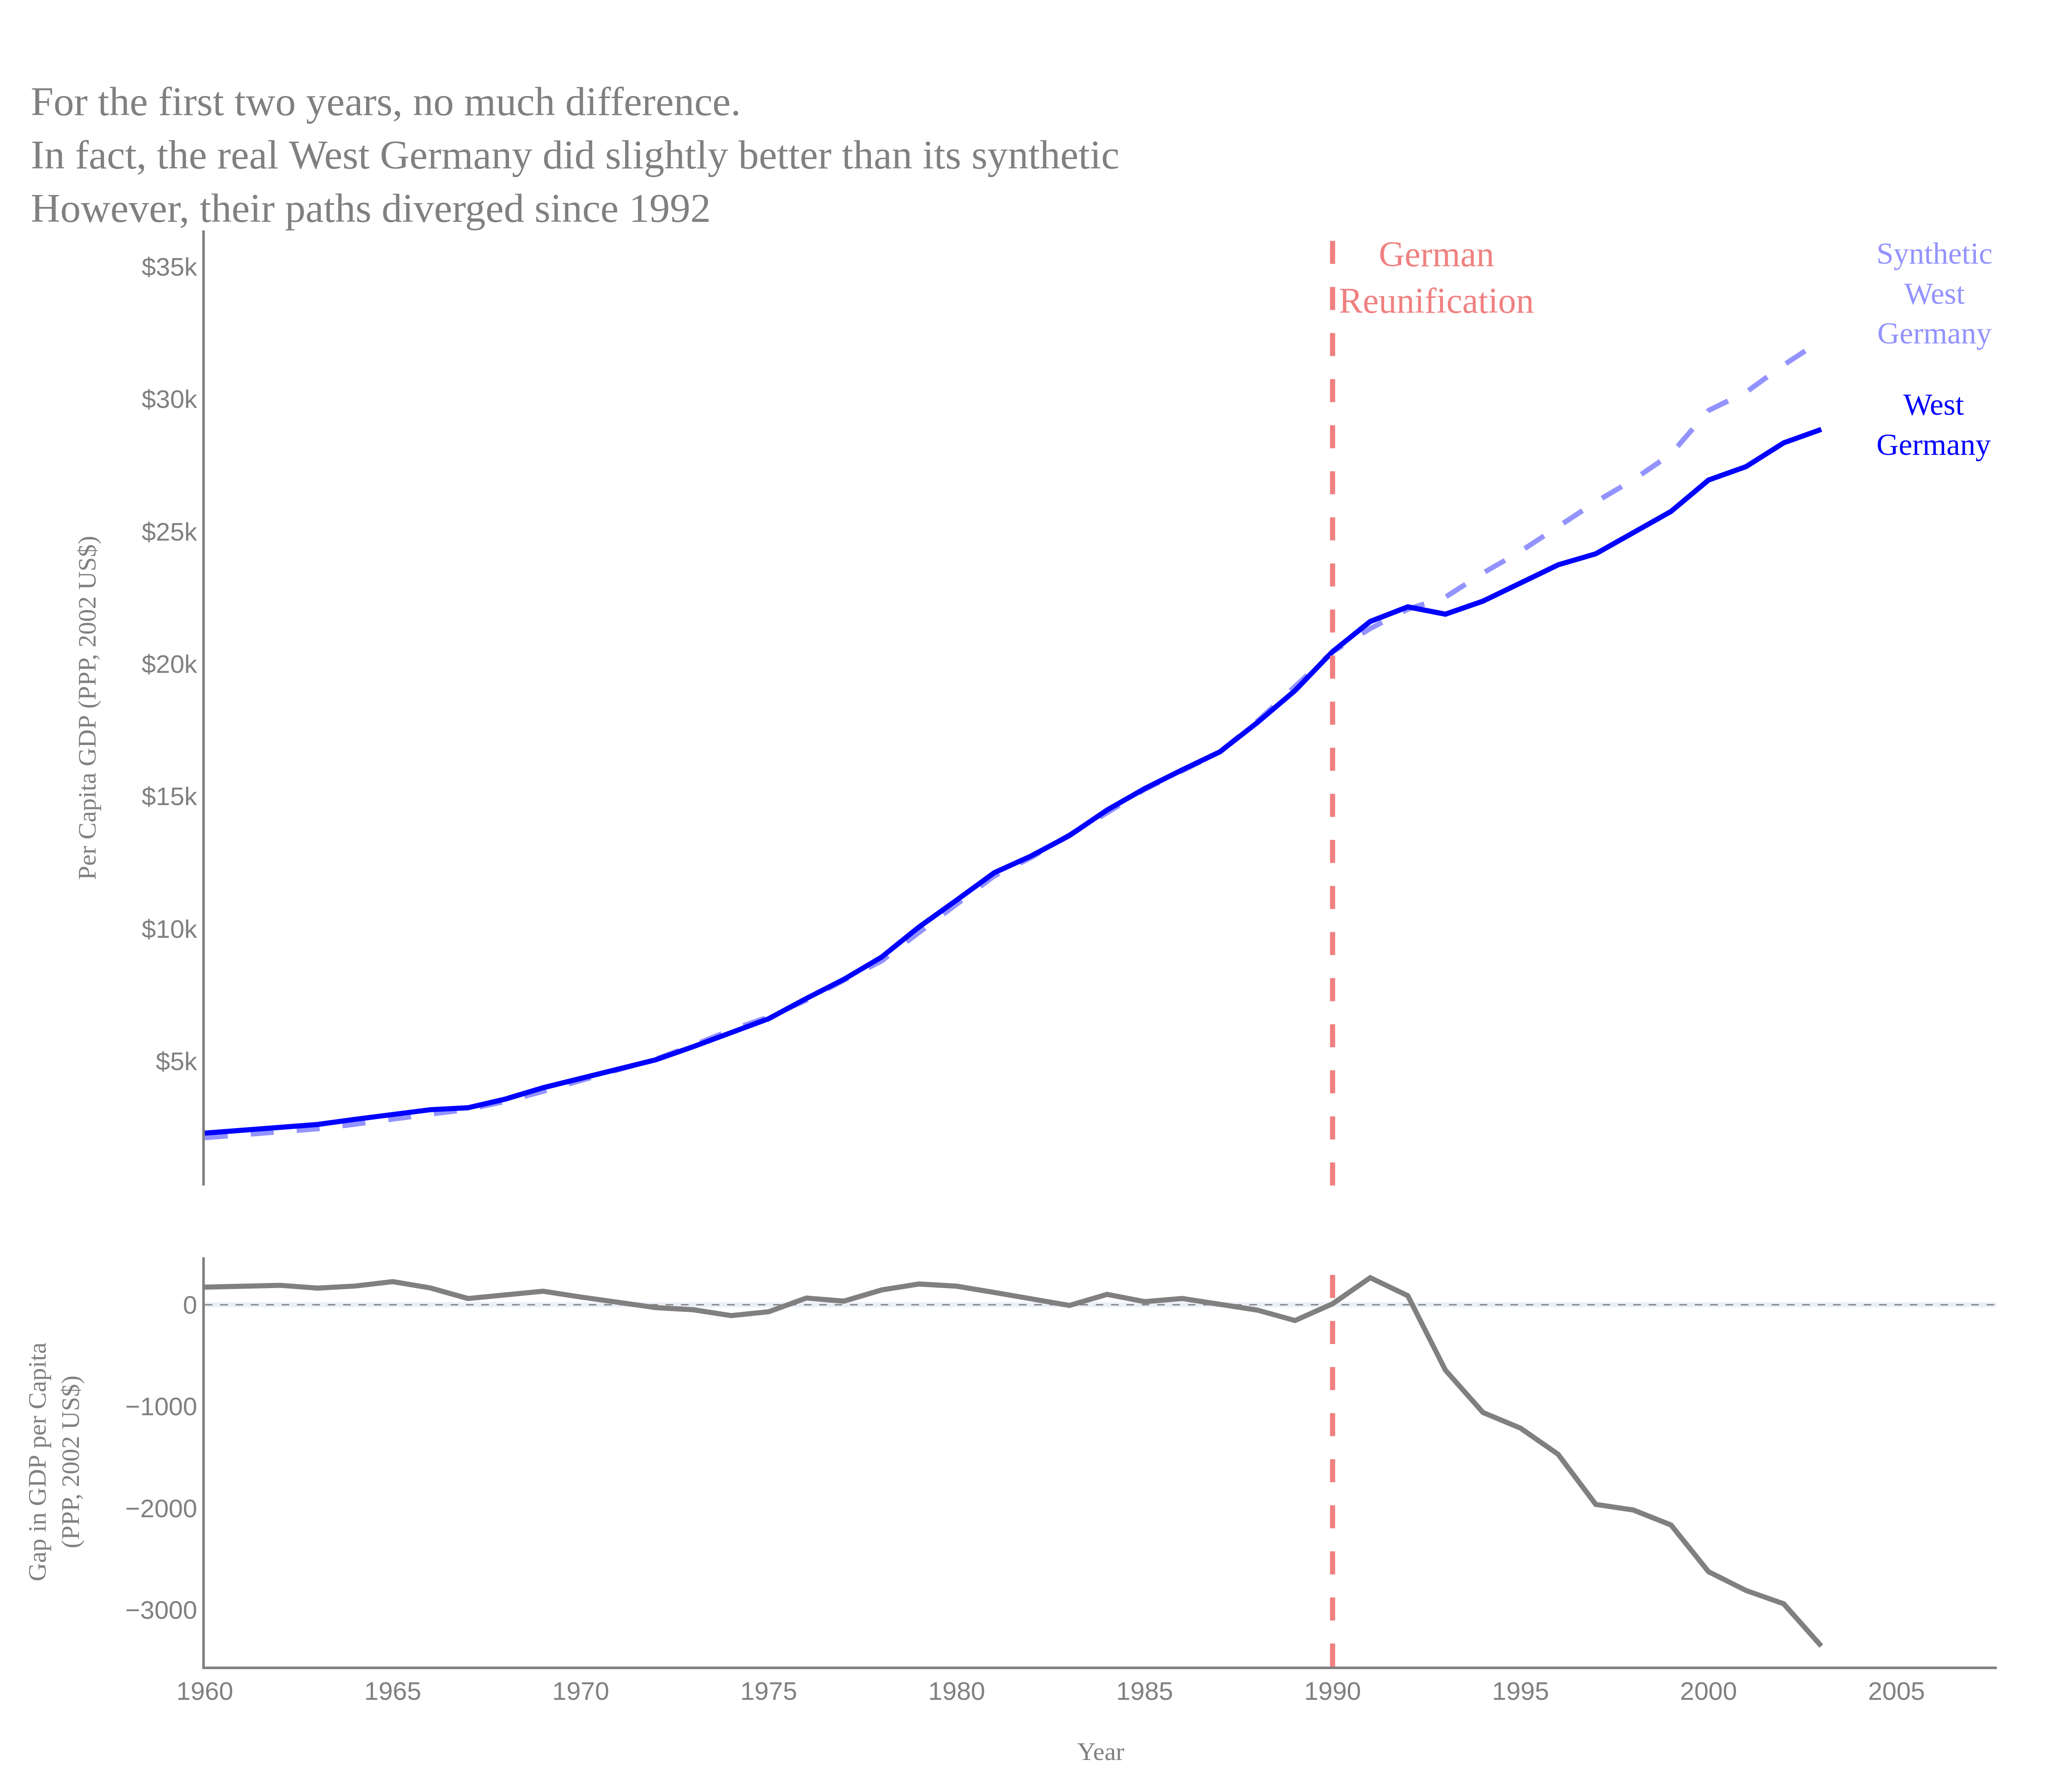

In [14]:
Image(filename="west_germany_synthetic_gap.png")

In [15]:
fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    subplot_titles=['Per Capita GDP', 'Inflation Rate (base year 1995)', 'Trade openness (Export plus imports as percentage of GDP)'])

alpha = 1
countries = ['Austria', 'West Germany', 'USA', 'Japan', 'Switzerlands', 'Netherlands']
max_year = 1990

def get_last_value(country_data, column):
    last_point = country_data[country_data[column].notnull()]
    if last_point.empty:
        return None, None
    x = last_point['year'].iloc[-1]
    y = last_point[column].iloc[-1]
    return x, y

for country in countries:
    country_data = df[df['country'] == country]
    country_data = country_data[country_data.year <= 1990]
    color = 'blue' if country == 'West Germany' else f'rgba(210, 210, 210, {alpha})'

    fig.add_trace(
        go.Scatter(
            x=country_data['year'],
            y=country_data['gdp'],
            mode='lines',
            line=dict(color=color),
            showlegend=False
        ),
        row=1, col=1
    )
    x_end, y_end = get_last_value(country_data, 'gdp')
    if x_end is not None and country == 'West Germany':
        fig.add_annotation(
            x=max_year + 1, y=y_end, text=country,
            showarrow=False, font=dict(color=color, size=10, family='dm sans'),
            xanchor='left', yanchor='middle', row=1, col=1
        )


    fig.add_trace(
        go.Scatter(
            x=country_data['year'],
            y=country_data['infrate'],
            mode='lines',
            line=dict(color=color),
            showlegend=False
        ),
        row=2, col=1
    )

    x_end, y_end = get_last_value(country_data, 'infrate')
    if x_end is not None and country == 'West Germany':
        fig.add_annotation(
            x=max_year + 1, y=y_end, text=country,
            showarrow=False, font=dict(color=color, size=10, family='dm sans'),
            xanchor='left', yanchor='middle', row=2, col=1
        )


    fig.add_trace(
        go.Scatter(
            x=country_data['year'],
            y=country_data['trade'],
            mode='lines',
            line=dict(color=color),
            showlegend=False
        ),
        row=3, col=1
    )
    x_end, y_end = get_last_value(country_data, 'trade')
    if x_end is not None and country == 'West Germany':
        fig.add_annotation(
            x=x_end, y=y_end, text=country,
            showarrow=False, font=dict(color=color, size=10, family='dm sans'),
            xanchor='left', yanchor='middle', row=3, col=1
        )

    alpha -= 0.1

fig.update_xaxes(
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title_text='Year',
    title_font=dict(color='grey', size=10, family='dm sans'),
    showgrid=False,
    row=3, col=1
)

# fig.add_annotation(
#     x=0.5, y=-0.2, xref="paper", yref="paper",
#     text=(
#         "GDP is Purchasing Power Parity (PPP)-adjusted and measured in 2002 US$.<br>"
#         "Source: Comparative Politics and the Synthetic Control Method (Abadie et al. 2015).<br>"
#         "Dataset: "
#         "<a href='https://github.com/OscarEngelbrektson/SyntheticControlMethods/blob/master/examples/datasets/german_reunification.csv'>"
#         "Download Source</a>."
#     ),
#     showarrow=False, font=dict(size=9, color="darkgrey", family='dm sans'), align="center"
# )

fig.update_layout(
    title='Preunification Trends: West Germany vs. Austria, USA, Japan, Switzerlands and Netherlands<br>(1960-1990)',
    height=600, width=900,
    template='plotly_white',
    margin=dict(t=90, r=20, b=10),
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
)


y_titles = [
    'Per Capita GDP<br>(PPP, 2002 US$)',
    'Inflation Rate (%)',
    '%'
]
for i, ytitle in enumerate(y_titles, start=1):
    fig.update_yaxes(
        title_text=ytitle,
        title_font=dict(color='grey', size=10, family='dm sans'),
        tickfont=dict(color='grey', size=10),
        tickcolor='grey',
        showgrid=False,
        row=i, col=1
    )
    fig.update_xaxes(
        showgrid=False,
        row=i, col=1
    )

fig.show()
fig.write_image("comparative_trends_preunification.png", scale=6)

The pre-unification trend plot also shows a parallel trajectories between West Germany and those countries

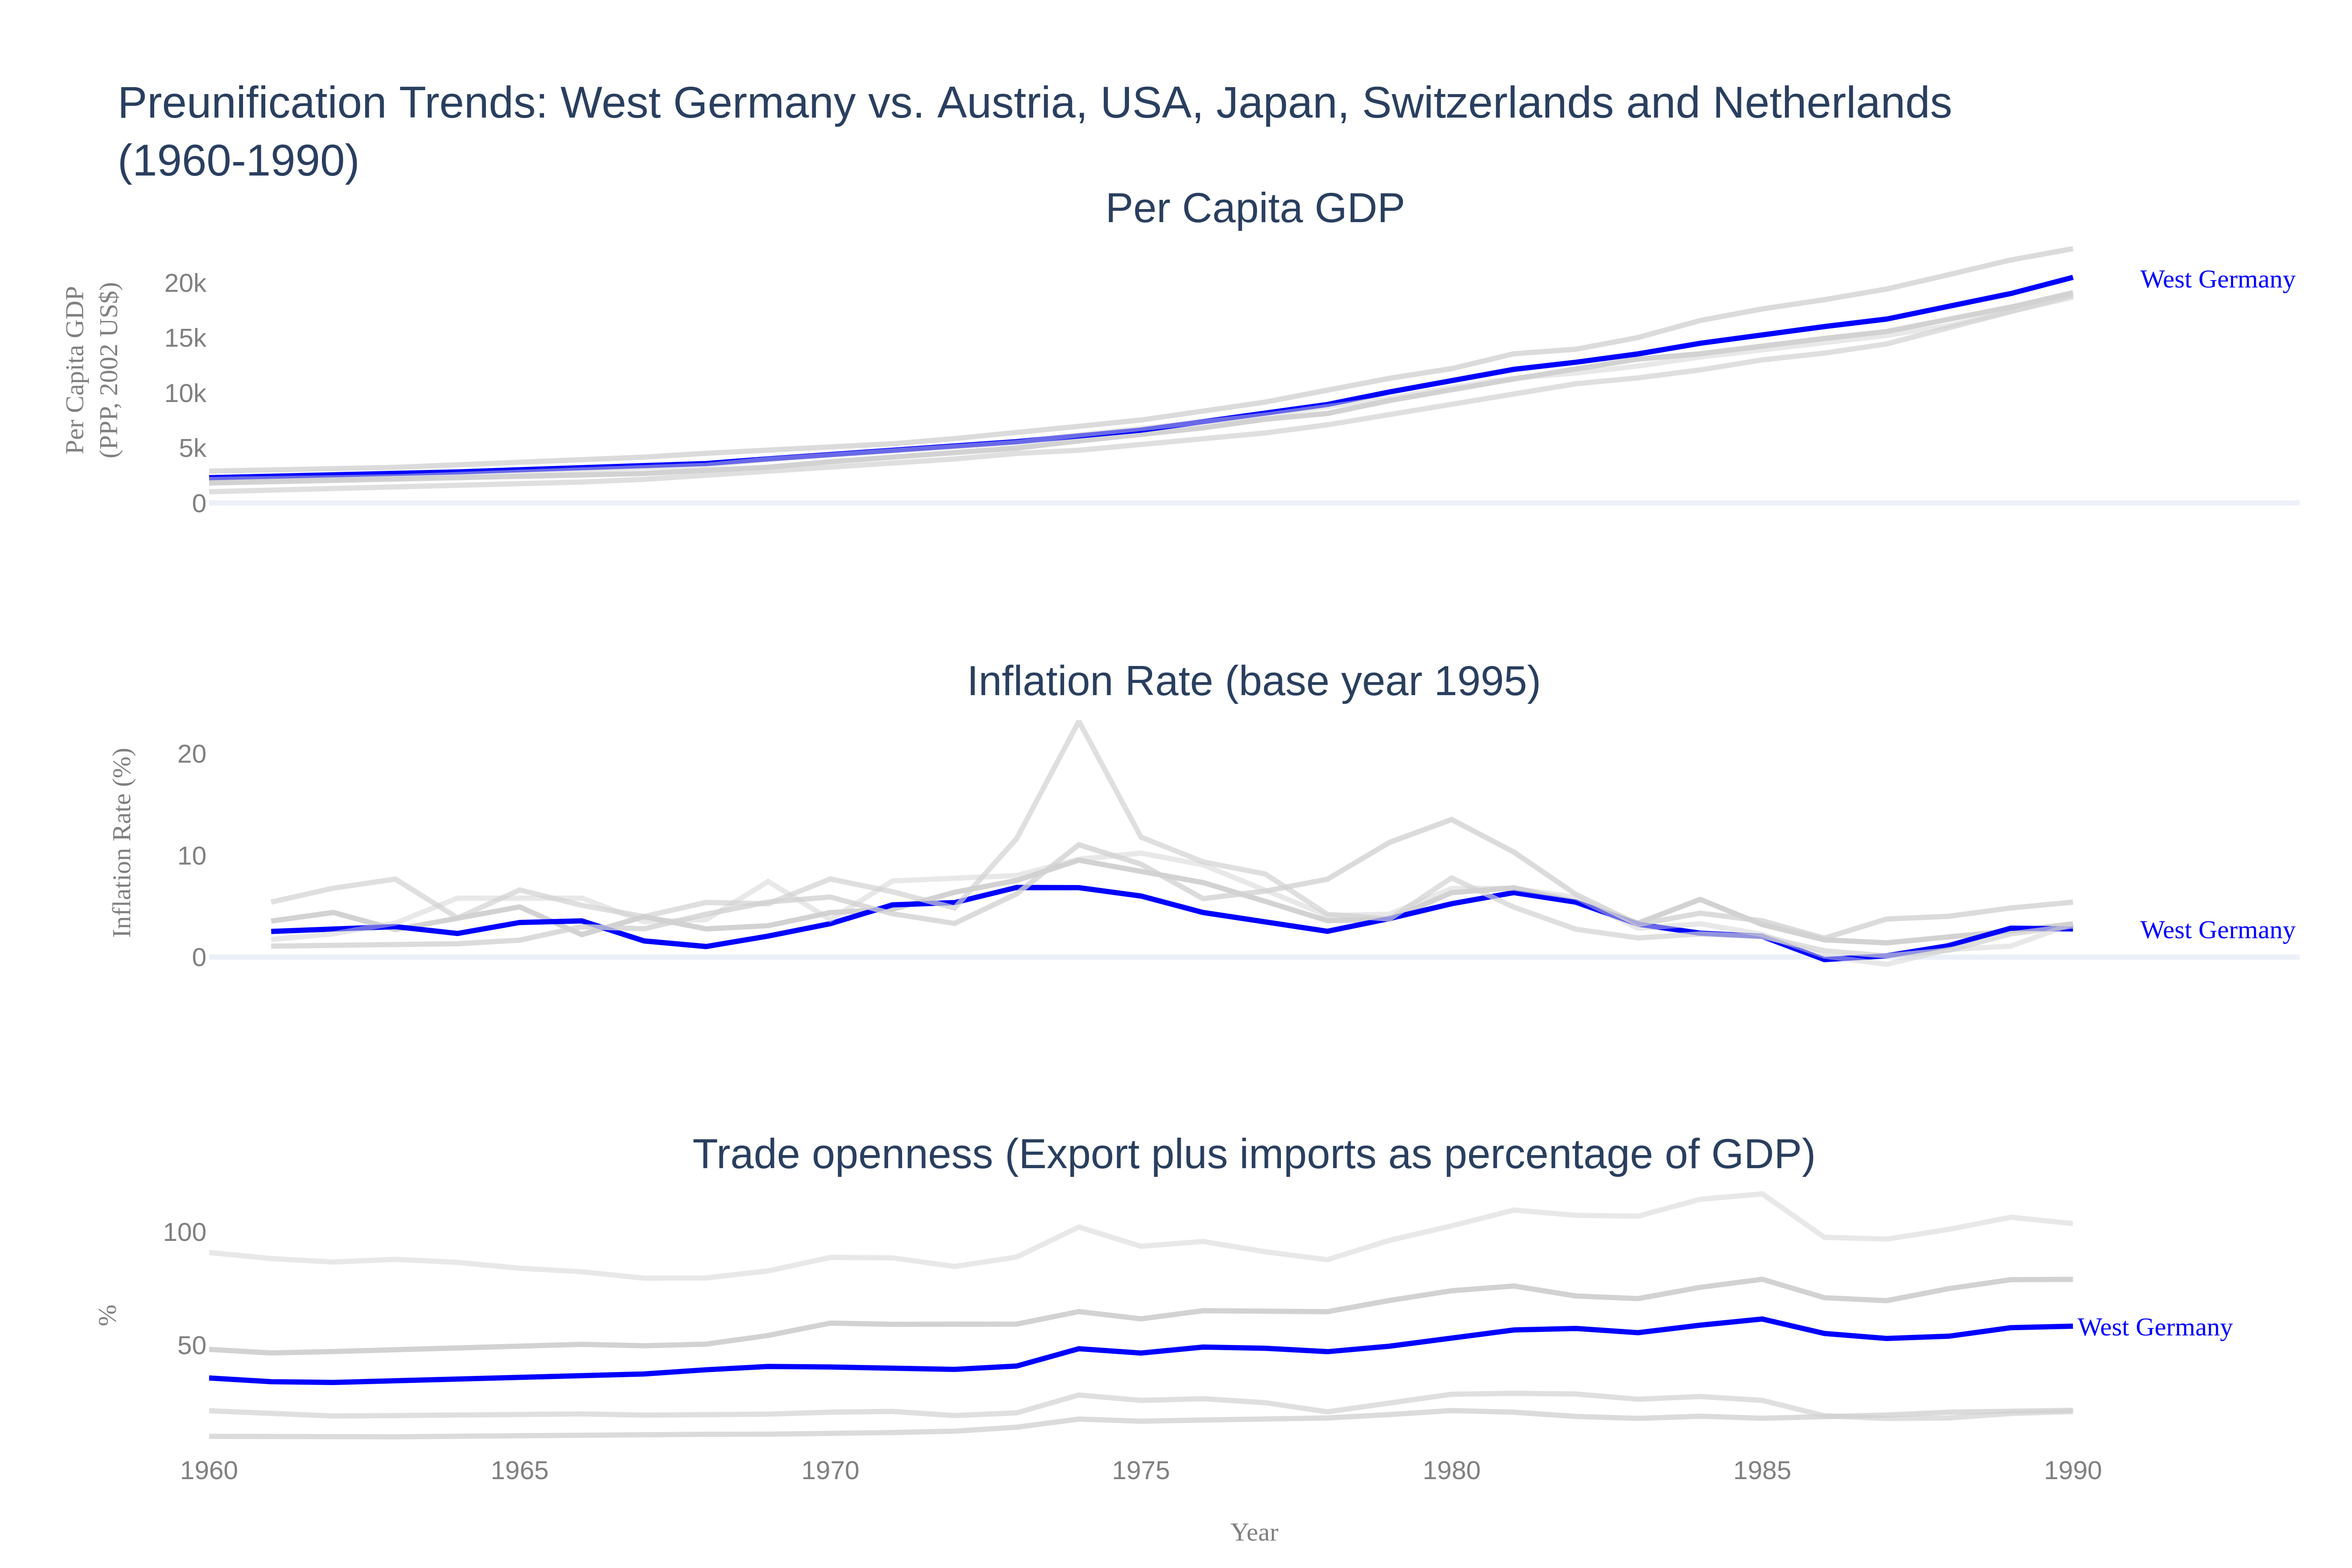

In [16]:
Image(filename="comparative_trends_preunification.png")

# MODEL VALIDATION

## IN-SPACE PLACEBO (SWAP TREATED COUNTRY TO OTHERS)

In [17]:
def run_placebo_tests(df: pd.DataFrame,
                      cov_df: pd.DataFrame,
                      treated_unit: str,
                      treatment_year: int,
                      outcome_col: str = 'gdp',
                      id_col: str = 'country',
                      time_col: str = 'year',
                      method: str = 'SLSQP',
                      verbose: bool = False) -> Dict:

    """
    Run placebo tests efficiently by pre-computing covariates once.

    Parameters
    ----------
    df : pd.DataFrame with original data
    cov_df : pd.DataFrame Covariate specifications
    treated_unit : str treatment unit ('West Germany')
    treatment_year : int Treatment year
    outcome_col : str, Outcome variable (gdp)
    id_col : str Unit ID (country)
    time_col : str Time identifier (year)
    method : str Scipy Optimization method

    Returns
    -------
    placebo_results : dict Store results for each placebo unit
    """

    Y_pivot = df.pivot(index=time_col, columns=id_col, values=outcome_col).sort_index()

    print("Start running placebo tests...")

    placebo_units = Y_pivot.columns.tolist()

    placebo_results = {}

    for i, unit in enumerate(placebo_units):
        print(f"  Placebo {i+1}/{len(placebo_units)}: {unit}")

        try:
            synth_df, w_opt, v_opt = synthetic_control_method(Y_pivot, cov_df, unit, treatment_year, method=method, verbose=verbose)

            # pre-treatment RMSPE
            pre_mask = synth_df['year'] < treatment_year
            pre_gap = synth_df.loc[pre_mask, 'Gap']
            pre_rmspe = np.sqrt(np.mean(pre_gap**2))

            # post-treatment RMSPE
            post_mask = synth_df['year'] >= treatment_year
            post_gap = synth_df.loc[post_mask, 'Gap']
            post_rmspe = np.sqrt(np.mean(post_gap**2))

            post_pre_rmspe_ratio = post_rmspe / pre_rmspe if pre_rmspe > 0 else np.inf

            placebo_results[unit] = {
                'synth_df': synth_df,
                'weights': w_opt,
                'v_weights': v_opt,
                'pre_rmspe': pre_rmspe,
                'post_rmspe': post_rmspe,
                'post_pre_rmspe_ratio': post_pre_rmspe_ratio
            }

        except Exception as e:
            print(f"    Failed for {unit}: {e}")
            continue

    print(f"Completed {len(placebo_results)} placebo tests.")

    print("\nPost and Pre RMSPE Ratio:")
    rmspe_summary = [(unit, res['post_pre_rmspe_ratio']) for unit, res in placebo_results.items()]
    rmspe_summary.sort(key=lambda x: x[1])

    for unit, rmspe in rmspe_summary:
        marker = " <-- TRUE TREATED" if unit == treated_unit else ""
        print(f"  {unit:20}: {rmspe:.4f}{marker}")

    return placebo_results

In [18]:
placebo_results = run_placebo_tests(df, cov_df, treated_unit='West Germany', treatment_year=1990)

Start running placebo tests...
  Placebo 1/17: Australia
  Placebo 2/17: Austria
  Placebo 3/17: Belgium
  Placebo 4/17: Denmark
  Placebo 5/17: France
  Placebo 6/17: Greece
  Placebo 7/17: Italy
  Placebo 8/17: Japan
  Placebo 9/17: Netherlands
  Placebo 10/17: New Zealand
  Placebo 11/17: Norway
  Placebo 12/17: Portugal
  Placebo 13/17: Spain
  Placebo 14/17: Switzerland
  Placebo 15/17: UK
  Placebo 16/17: USA
  Placebo 17/17: West Germany
Completed 17 placebo tests.

Post and Pre RMSPE Ratio:
  Portugal            : 0.9269
  Austria             : 0.9424
  Switzerland         : 1.3249
  Denmark             : 1.5297
  UK                  : 1.6361
  Belgium             : 2.2489
  France              : 2.3243
  Netherlands         : 2.4220
  Italy               : 2.5316
  USA                 : 3.4637
  Spain               : 3.6857
  New Zealand         : 3.7787
  Greece              : 4.0245
  Australia           : 5.4495
  Japan               : 6.1440
  Norway              : 8.3231


In [19]:
from plotly.subplots import make_subplots

sorted_results = sorted(placebo_results.items(), key=lambda x: x[1]['post_pre_rmspe_ratio'], reverse=False)
units = [unit for unit, res in sorted_results]
ratios = [res['post_pre_rmspe_ratio'] for unit, res in sorted_results]

colors = []
for i in range(len(ratios)):
    if i == len(ratios) - 1:
        colors.append('rgba(0, 0, 255, 1.0)')
    elif i == len(ratios) - 2:
        colors.append('rgba(0, 0, 255, 0.5)')
    elif i == len(ratios) - 3:
        colors.append('rgba(0, 0, 255, 0.2)')
    else:
        colors.append('lightgrey')

treated_ratio = placebo_results[treated_unit]['post_pre_rmspe_ratio'] if treated_unit in placebo_results else None


fig = make_subplots(rows=1, cols=2, subplot_titles=[
    "West Germany has the highest Post-/Pre- RMSPE ratio<br>Post-reunification gap ≅ 16 x pre-reunification gap",
    "Histogram distribution of Post-/Pre- RMSPE<br>across in-space placebo units"
])

# Bar
fig.add_trace(go.Bar(
    x=ratios,
    y=units,
    orientation='h',
    marker=dict(color=colors),
    name='Post/Pre RMSPE Ratio'
), row=1, col=1)


# Hist
treated_unit = 'West Germany'
other_ratios = [r for u, r in zip(units, ratios) if u != treated_unit]

fig.add_trace(go.Histogram(
    x=other_ratios,
    nbinsx=10,
    marker=dict(color='lightgrey', line=dict(color='lightgrey', width=1)),
    name='Histogram of Ratios'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=[treated_ratio],
    y=[1],
    marker=dict(color='rgba(0, 0, 255, 1.0)', line=dict(color='rgba(0, 0, 255, 1.0)', width=1)),
    name=f'{treated_unit} Ratio'
), row=1, col=2)

fig.add_annotation(x=treated_ratio - 2,
                   y=1.2,
                   xref='x2', yref='y2',
                   text=f'{treated_unit}',
                   showarrow=True, arrowhead=2,
                   ax=40, ay=0, font=dict(color='rgba(0, 0, 255, 1.0)', size=14, family="dm sans"))


fig.update_xaxes(title_text='Post-/Pre- RMSPE Ratio', row=1, col=1,  tickfont=dict(family="dm sans", color='grey'), showgrid=False,
                 title_font=dict(color='grey', size=10, family='dm sans'),
                 linecolor='grey',
                 tickcolor='grey')

fig.update_yaxes(title_text='', row=1, col=1, tickfont=dict(family="dm sans", color='black'), showgrid=False)
fig.update_xaxes(title_text='Post-/Pre- RMSPE Ratio', row=1, col=2, tickfont=dict(family="dm sans", color='grey'), showgrid=False,
                 title_font=dict(color='grey', size=10, family='dm sans'),
                 linecolor='grey',
                 tickcolor='grey'
                 )
fig.update_yaxes(title_text='Frequency', row=1, col=2,  tickfont=dict(family="dm sans", color='grey',),  showgrid=False,
                 title_font=dict(color='grey', size=10, family='dm sans'),
                 linecolor='grey',
                 tickcolor='grey'
                 )


fig.update_layout(
    height=600,
    width=1200,
    template='plotly_white',
    showlegend=False,
    margin=dict(t=50, r=20, b=10),
)



fig.show()
fig.write_image("inspace_placebo.png", scale=6)

The effect observed for West Germany was the most extreme (highest post-/pre- RMSE ratio - Post-reunification gap is 16 times higher than pre-reunification).
If we randomly pick a country from the sample, the chances of getting such a large gap by random chance would be 1/17≅0.059.

In [20]:
# Image(filename="inspace_placebo.png")

## IN-TIME PLACEBO (BACKDATING THE TREATMENT TIME - 8 YEARS EARLIER)

### NEED TO RECALCULATE TIME-DEPENDENT COVARIATES

In [21]:
time_col, id_col, outcome_col = 'year', 'country', 'gdp'
treated_unit, placebo_treatment_year = 'West Germany', 1982

# Recalculate Covariate Specification which can affect West Germany GDP
covariate_spec = {
    'gdp_avg': ('gdp', 'mean', (1981, placebo_treatment_year)),           # AVG GDP per capita 1981-1982
    'trade_avg': ('trade', 'mean', (1981, placebo_treatment_year)),       # Avg Trade openness 1981-1982
    'infrate_avg': ('infrate', 'mean', (1981, placebo_treatment_year)),   # Avg Inflation rate 1981-1982
    'industry_avg': ('industry', 'mean', (1981, placebo_treatment_year)),      # Avg Industry share 1981-1982
    'schooling_avg': ('schooling', 'mean', [1980, placebo_treatment_year]),    # Avg Schooling 1980 and 1982
    'invest80': ('invest80', 'mean', (1980, placebo_treatment_year))           # Avg Investment rate 1980-1982
}

cov_df = prepare_covariate(df, covariate_spec)
display(cov_df)
synth_df, w_opt, v_opt = synthetic_control_method(df_pivot, cov_df, treated_unit, placebo_treatment_year, method='SLSQP')

,gdp_avg,trade_avg,infrate_avg,industry_avg,schooling_avg,invest80
country,,,,,,
Australia,11525.0,32.415731,10.418627,35.334005,47.500000,29.695999
Austria,11695.0,73.882115,6.123638,37.367720,61.799999,26.642000
Belgium,11453.0,130.388145,8.177063,34.435686,31.600000,21.875999
Denmark,11610.5,74.160832,10.940765,26.667175,43.400002,22.217999
France,11399.0,45.801623,12.655905,34.635815,34.500000,27.236000
Greece,8037.0,38.906338,22.688970,31.616159,19.700001,24.002001
Italy,10934.0,47.974222,17.088735,38.585816,29.200001,26.728001
Japan,10399.5,28.502583,3.824142,40.618521,39.900002,34.986000
Netherlands,11544.0,108.475625,6.305268,34.407702,44.099998,21.840000


In [22]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=synth_df['year'], y=synth_df['Treated'], mode='lines', name=country,
                          line=dict(color='blue'), showlegend=False))
fig.add_trace(go.Scatter(x=synth_df['year'], y=synth_df['Synthetic'], mode='lines', name=country, opacity=0.5,
                          line=dict(color='rgba(0, 0, 255, 0.85)', dash="dash"), showlegend=False))

fig.add_annotation(x=2006, y=29000, text="West<br>Germany", opacity=1,
                   font=dict(family="dm sans", color='blue'), showarrow=False, arrowhead=1, arrowsize=1, arrowwidth=1, ax=20)
fig.add_annotation(x=2006, y=34000, text="Synthetic<br>West<br>Germany",
                   font=dict(family="dm sans",color='rgba(0, 0, 255, 0.85)'), opacity=0.5, showarrow=False, arrowhead=1, arrowsize=1, arrowwidth=1, ax=20)


fig.add_vline(x=treatment_year, line=dict(color="lightcoral", width=2, dash="dash"), opacity=0.5
              ,annotation_text="German<br>Reunification<br>(Real Treatment Year)", annotation_position="top right"
              ,annotation_font=dict(color="rgba(240, 128, 128, 0.5)", size=14, family="dm sans"))

fig.add_vline(x=placebo_treatment_year, line=dict(color="green", width=2, dash="dash")
              ,annotation_text="Fake treatment year<br>(placebo test)", annotation_position="top left"
              ,annotation_font=dict(color="green", size=14, family="dm sans"))


fig.update_layout(
    title=f"""When we fake the reunification in 1982 (8 years earlier) and rerun the model,<br>two lines did not diverge considerably before the actual year 1990.
<br>This means this in-time placebo reunification has no observable effect""",
    xaxis_title='Year',
    yaxis_title='Per Capita GDP (PPP, 2002 US$)',
    yaxis_tickprefix='$',
    template='plotly_white',
    height=600,width=1000,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    margin=dict(t=120, r=20, b=15)
)

fig.update_xaxes(
    showgrid=False,
    linecolor='lightgrey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title_text='Year',
    title_font=dict(color='grey', size=10, family='dm sans'),
)

fig.update_yaxes(
    title_font=dict(color='grey', size=10, family='dm sans'),
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
)



# Show plot
fig.show()
fig.write_image("intime_placebo.png", scale=6)


In this fake treatment year scenario, the synthetic West Germany almost exactly reproduces the evolution of per capita GDP in the actual West Germany before any fake treatment period. Most importantly, the per capita GDP trajectories of West Germany and its synthetic counterpart did not diverge considerably before the actual year 1990.
This means this placebo reunification has no observable effect. This suggests that the divergence in 1990 was not a random artifact of the model. The gap confidently reflects the impact of the German reunification.

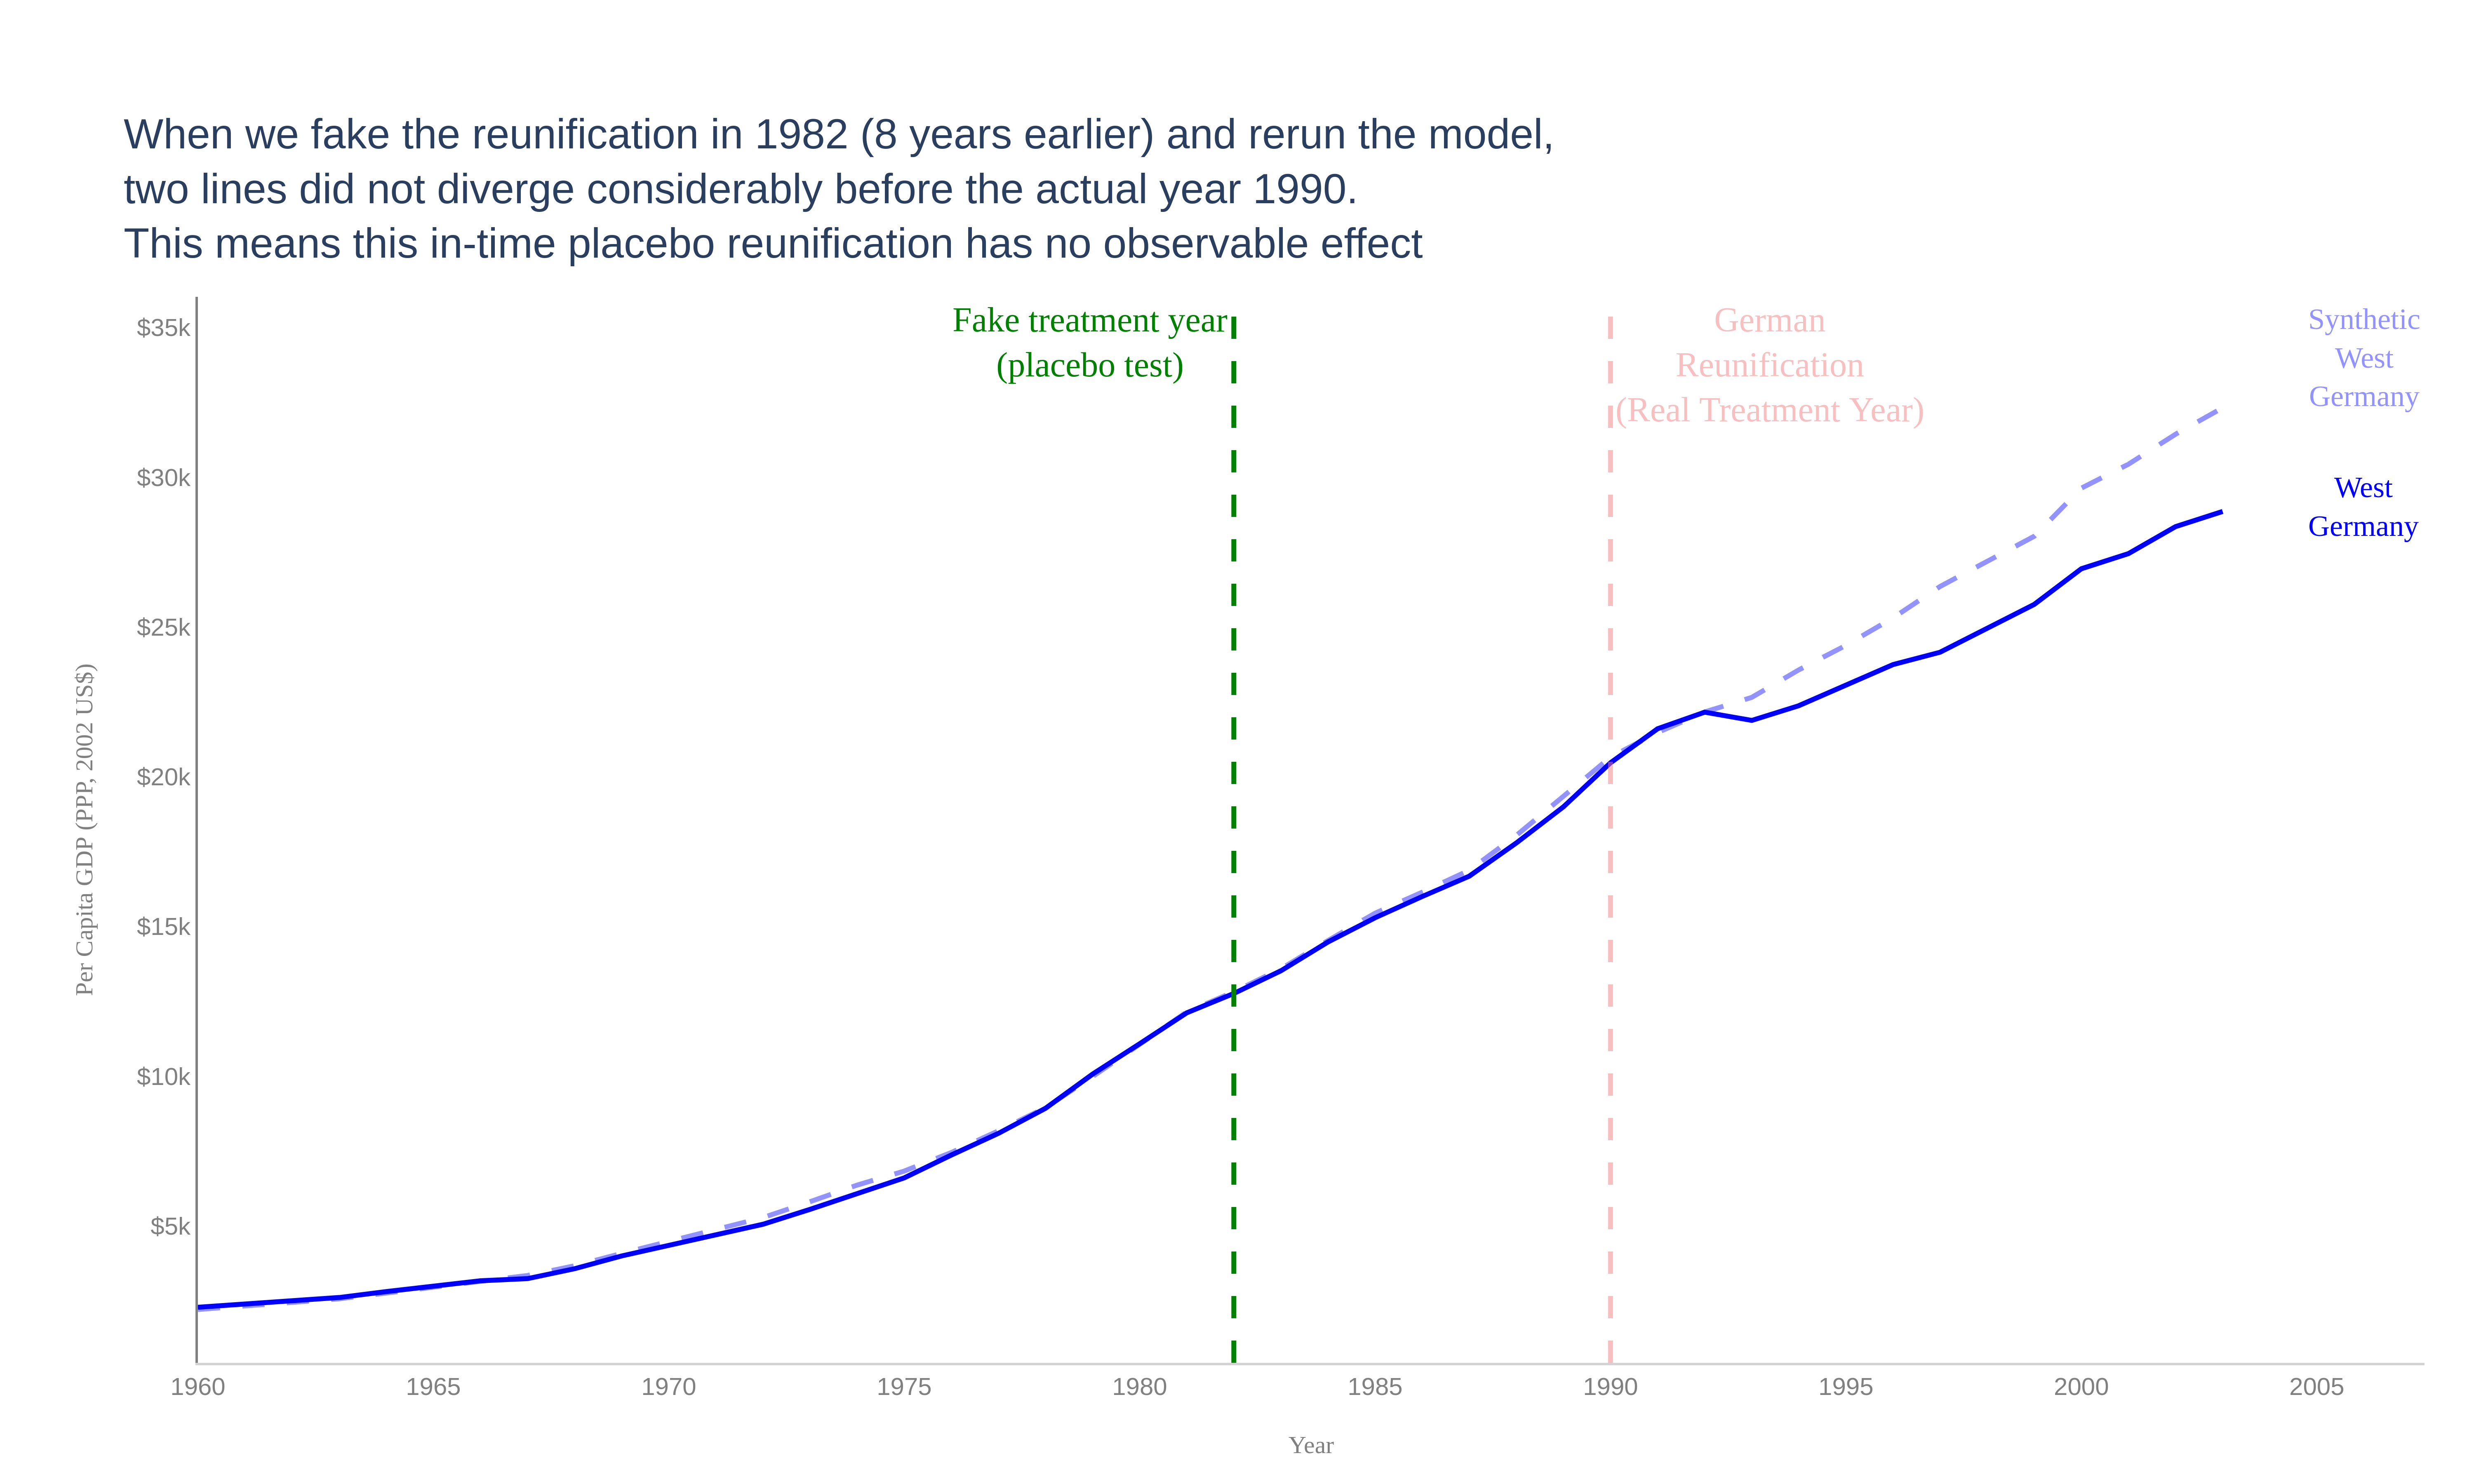

In [23]:
Image(filename="intime_placebo.png")

## Leave One Out (Remove one donor, one after the other and rerun the model)

### REDEFINE COVARIATES WITH CORRECT TREATMENT YEAR
#### Remove selected donors, one after the other from modeling

In [24]:
time_col, id_col, outcome_col = 'year', 'country', 'gdp'
treated_unit, treatment_year = 'West Germany', 1990


# Covariate Specification which can affect West Germany GDP
covariate_spec = {
    'gdp_avg': ('gdp', 'mean', (1981, treatment_year)),           # AVG GDP per capita 1981-90
    'trade_avg': ('trade', 'mean', (1981, treatment_year)),       # Avg Trade openness 1981-90
    'infrate_avg': ('infrate', 'mean', (1981, treatment_year)),   # Avg Inflation rate 1981-90
    'industry_avg': ('industry', 'mean', (1981, 1989)),           # Avg Industry share 1981-1989
    'schooling_avg': ('schooling', 'mean', [1980, 1985]),         # Avg Schooling 1980-85
    'invest80': ('invest80', 'mean', (1980, 1984))                        # Avg Investment rate 1980-85 (using invest80 as proxy, already average)
}

loo_dict = {}
# remove selected donors, one after the other from modeling
for nation in ['Austria', 'USA', 'Japan']:
  df_loo = df[df.country != nation]
  df_loo_pivot = df_loo.pivot(index=time_col, columns=id_col, values=outcome_col).sort_index()
  cov_df = prepare_covariate(df_loo, covariate_spec)
  synth_df, _, _ = synthetic_control_method(df_loo_pivot, cov_df, treated_unit, treatment_year, method='SLSQP')
  loo_dict[nation] = synth_df

In [25]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=df[df.country=='West Germany']['year'], y=df[df.country=='West Germany']['gdp'], mode='lines', name=country,
                                 line=dict(color='blue'), showlegend=False))

fig.add_trace(go.Scatter(x=synth_df_Germany['year'], y=synth_df_Germany['Synthetic'], mode='lines', name=f"Synthetic West Germany", opacity=0.5,
                          line=dict(color='rgba(0, 0, 255, 0.85)', dash="dash"), showlegend=True))
alpha = 1
for country, plot_data in loo_dict.items():

    fig.add_trace(go.Scatter(x=plot_data['year'], y=plot_data['Synthetic'], mode='lines', name=f"Leave {country} out",
    # ,opacity=0.5,
                                 line=dict(color=f'rgba(169, 169, 169, {alpha})'), showlegend=True))
    alpha = alpha - 0.35

fig.add_annotation(x=2006, y=29000, text="West<br>Germany", font=dict(family="dm sans", color='blue'), showarrow=False, arrowhead=1, arrowsize=1, arrowwidth=1, ax=20)

# fig.add_annotation(
#     x=0.5, y=-0.15, xref="paper", yref="paper",
#     text="GDP is Purchasing Power Parity (PPP)-adjusted and measured in 2002 US$<br>Source: Comparative Politics and the Synthetic Control Method (Abadie et al. 2015)<br>Download Source: https://github.com/OscarEngelbrektson/SyntheticControlMethods/blob/master/examples/datasets/german_reunification.csv",
#     showarrow=False, font=dict(size=10, color="darkgrey", family='dm sans'), align="left"
# )


fig.add_vline(x=1990, line=dict(color="lightcoral", width=2, dash="dash")
              ,annotation_text="German<br>Reunification", annotation_position="top right"
              ,annotation_font=dict(color="lightcoral", size=14, family="dm sans"))


fig.update_layout(
    title='When we leave one country out in modeling, we still found a significant impact<br>even in the worst-case scenario when USA was omitted from the model',
    xaxis_title='',
    yaxis_title='Per Capita GDP (PPP, 2002 US$)',
    yaxis_tickprefix='$',
    template='plotly_white',
    height=600,width=1000,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    margin=dict(t=80, r=20, b=15)
)

fig.update_xaxes(
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title_text='Year',
    title_font=dict(color='grey', size=10, family='dm sans'),
)

fig.update_yaxes(
    # title_text='Gap in GDP per Capita',
    title_font=dict(color='grey', size=10, family='dm sans'),
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
)

# Show plot
fig.show()
fig.write_image("loo_test.png", scale=6)


The new results were very similar to our original findings. Even in the worst-case scenario, when we left out the USA from the model, we still found a significant impact. In short, this extra test shows that we are confident about this finding.

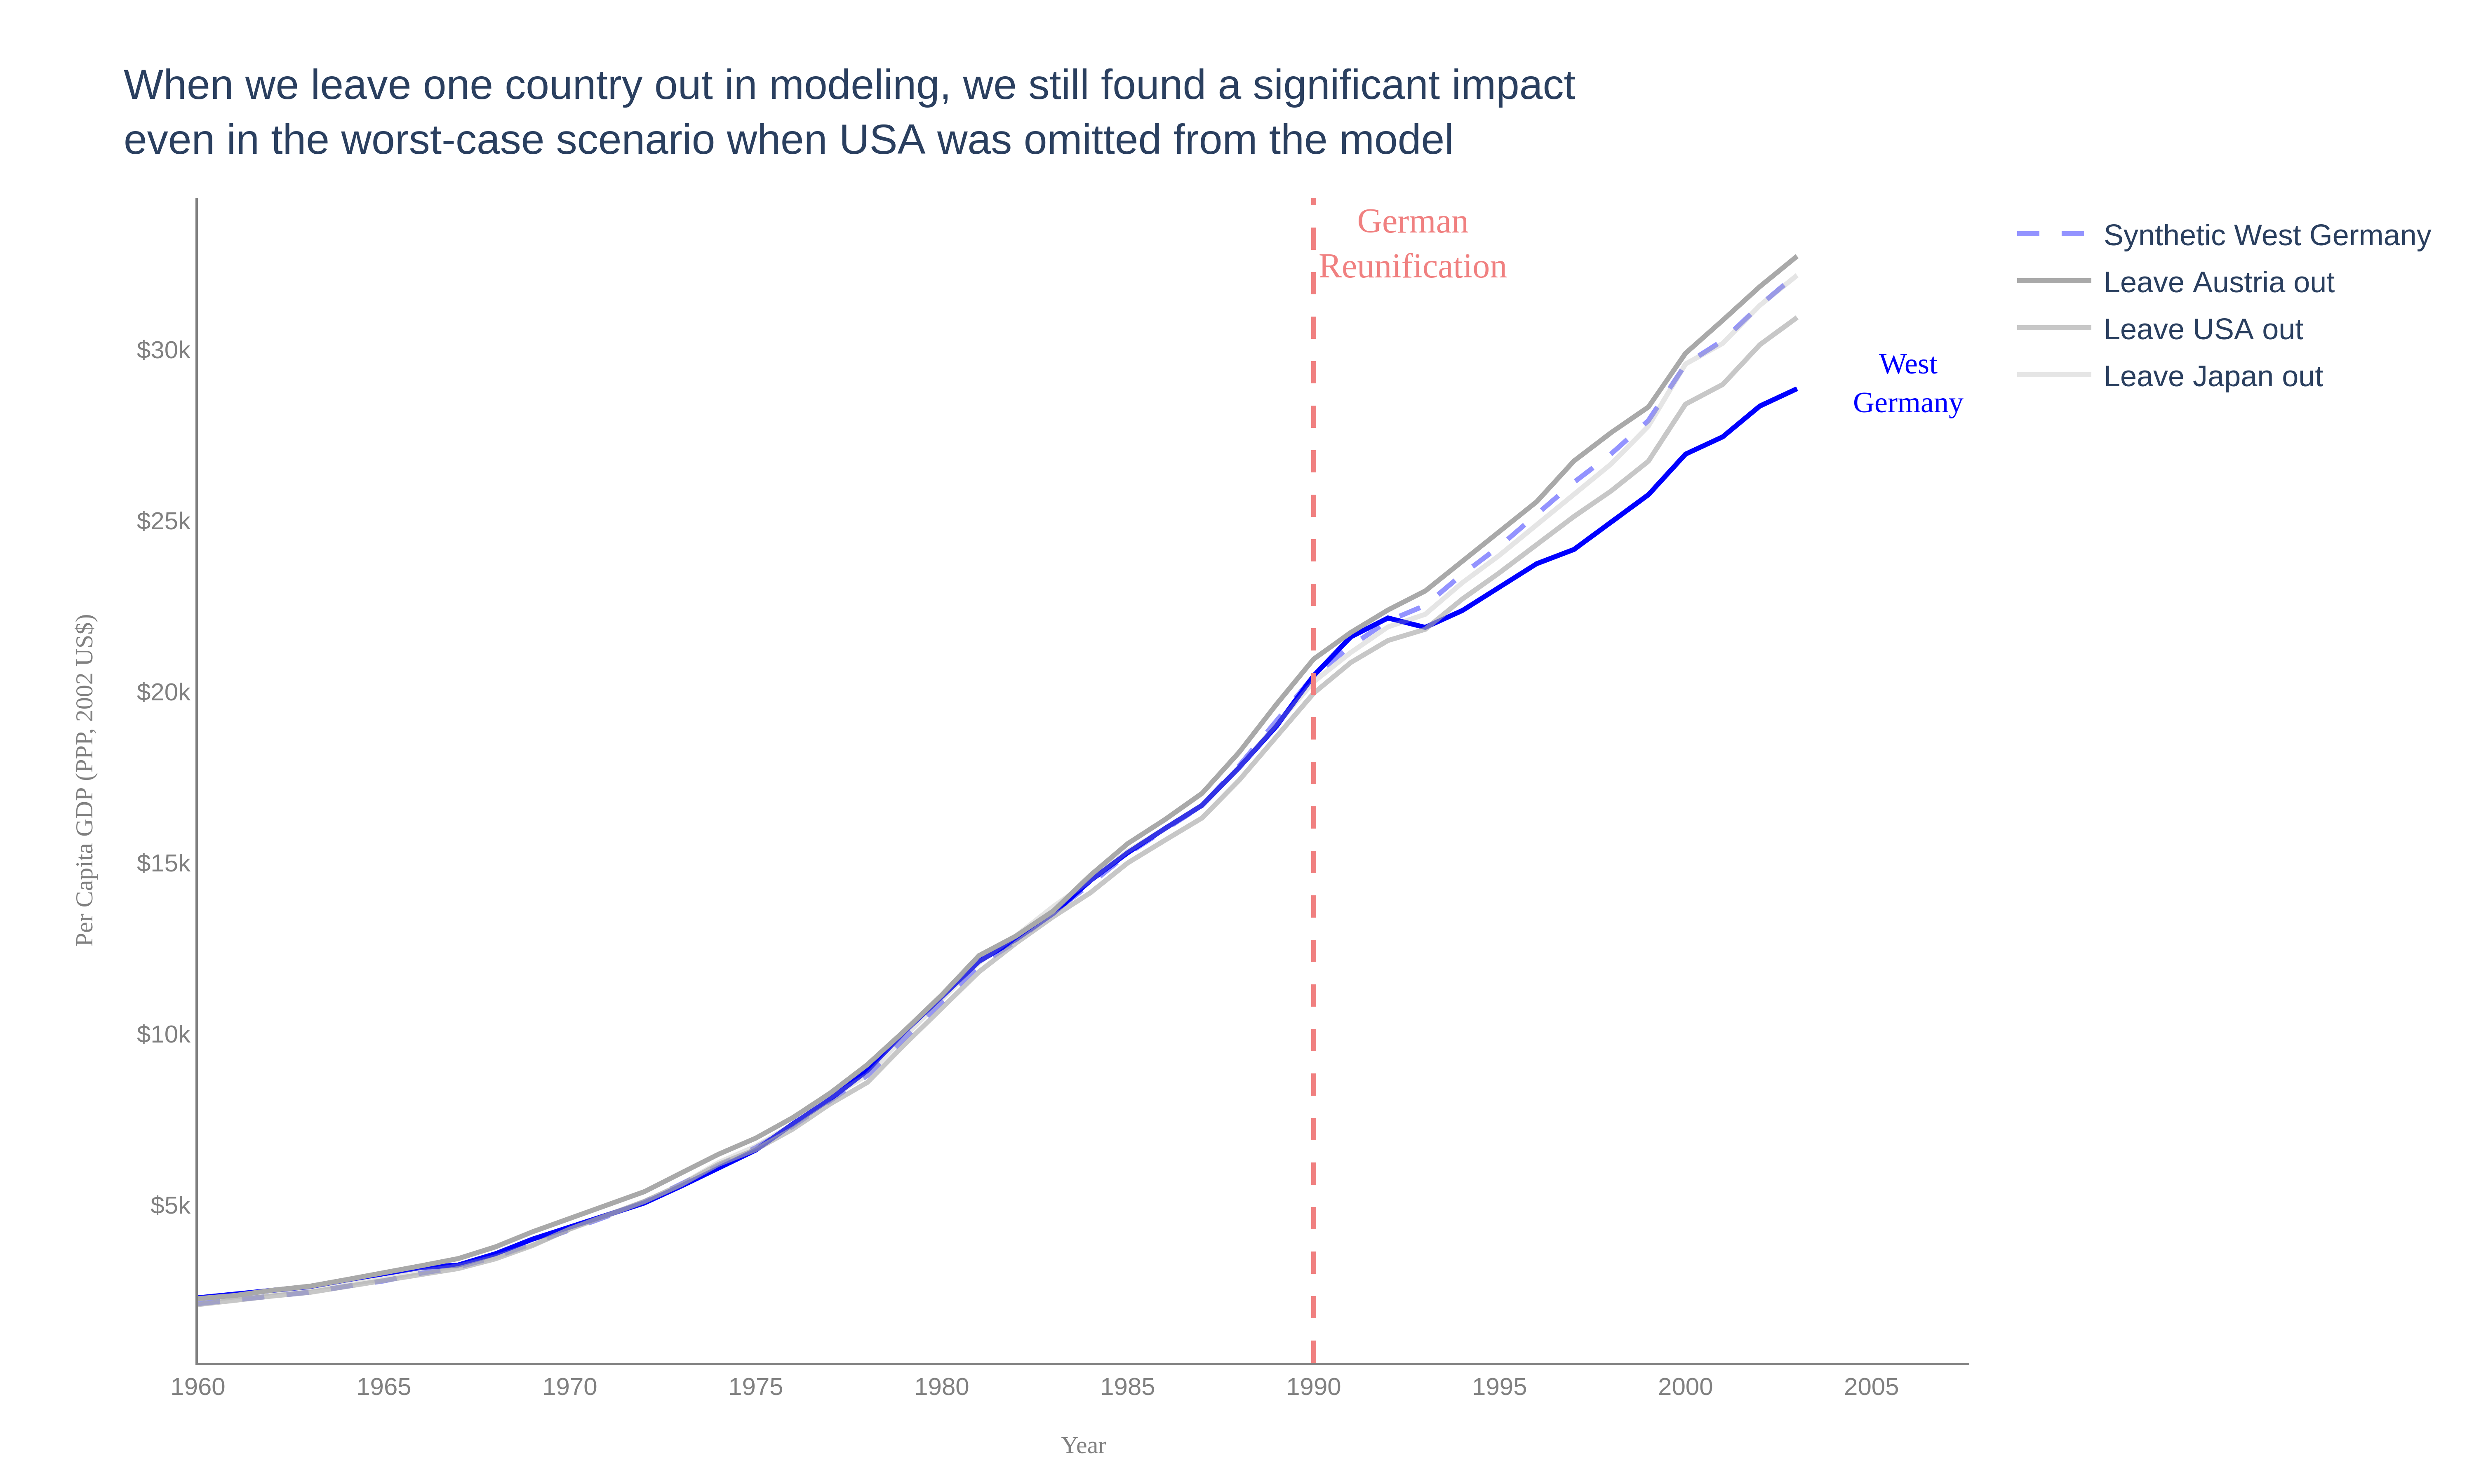

In [26]:
Image(filename="loo_test.png")